# Chinook DB Tables

Load every table from `chinook.db` into its own pandas DataFrame.

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd

DB_PATH = Path("chinook.db")
assert DB_PATH.exists(), f"Database not found at {DB_PATH.resolve()}"

conn = sqlite3.connect(DB_PATH)
conn

## Load every table into a DataFrame

One variable per table, following the same `pd.read_sql_query` pattern used in `cost_analysis_notebook.ipynb`. Date columns are parsed where present."

In [2]:
albums = pd.read_sql_query("SELECT * FROM Album", conn)
artists = pd.read_sql_query("SELECT * FROM Artist", conn)
customers = pd.read_sql_query("SELECT * FROM Customer", conn)
employees = pd.read_sql_query(
    "SELECT * FROM Employee", conn, parse_dates=["BirthDate", "HireDate"]
)
genres = pd.read_sql_query("SELECT * FROM Genre", conn)
invoices = pd.read_sql_query("SELECT * FROM Invoice", conn, parse_dates=["InvoiceDate"])
invoice_items = pd.read_sql_query("SELECT * FROM InvoiceLine", conn)
media_types = pd.read_sql_query("SELECT * FROM MediaType", conn)
playlists = pd.read_sql_query("SELECT * FROM Playlist", conn)
playlist_tracks = pd.read_sql_query("SELECT * FROM PlaylistTrack", conn)
tracks = pd.read_sql_query("SELECT * FROM Track", conn)

print(f"albums:          {albums.shape}")
print(f"artists:         {artists.shape}")
print(f"customers:       {customers.shape}")
print(f"employees:       {employees.shape}")
print(f"genres:          {genres.shape}")
print(f"invoices:        {invoices.shape}")
print(f"invoice_items:   {invoice_items.shape}")
print(f"media_types:     {media_types.shape}")
print(f"playlists:       {playlists.shape}")
print(f"playlist_tracks: {playlist_tracks.shape}")
print(f"tracks:          {tracks.shape}")

albums:          (347, 3)
artists:         (275, 2)
customers:       (59, 13)
employees:       (8, 15)
genres:          (25, 2)
invoices:        (412, 9)
invoice_items:   (2240, 5)
media_types:     (5, 2)
playlists:       (18, 2)
playlist_tracks: (8715, 2)
tracks:          (3503, 9)


## Peek at each table

Preview the first few rows of every table."

In [3]:
albums.head()

,AlbumId,Title,ArtistId
0,1,For Those About To Rock We Salute You,1
1,2,Balls to the Wall,2
2,3,Restless and Wild,2
3,4,Let There Be Rock,1
4,5,Big Ones,3


In [4]:
artists.head()

,ArtistId,Name
0,1,AC/DC
1,2,Accept
2,3,Aerosmith
3,4,Alanis Morissette
4,5,Alice In Chains


In [5]:
customers.head()

,CustomerId,FirstName,LastName,Company,Address,City,State,Country,PostalCode,Phone,Fax,Email,SupportRepId
0,1,Luís,Gonçalves,Embraer - Empresa Brasileira de Aeronáutica S.A.,"Av. Brigadeiro Faria Lima, 2170",São José dos Campos,SP,Brazil,12227-000,+55 (12) 3923-5555,+55 (12) 3923-5566,luisg@embraer.com.br,3
1,2,Leonie,Köhler,None,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,+49 0711 2842222,None,leonekohler@surfeu.de,5
2,3,François,Tremblay,None,1498 rue Bélanger,Montréal,QC,Canada,H2G 1A7,+1 (514) 721-4711,None,ftremblay@gmail.com,3
3,4,Bjørn,Hansen,None,Ullevålsveien 14,Oslo,None,Norway,0171,+47 22 44 22 22,None,bjorn.hansen@yahoo.no,4
4,5,František,Wichterlová,JetBrains s.r.o.,Klanova 9/506,Prague,None,Czech Republic,14700,+420 2 4172 5555,+420 2 4172 5555,frantisekw@jetbrains.com,4


In [6]:
employees.head()

,EmployeeId,LastName,FirstName,Title,ReportsTo,BirthDate,HireDate,Address,City,State,Country,PostalCode,Phone,Fax,Email
0,1,Adams,Andrew,General Manager,NaN,1962-02-18,2002-08-14,11120 Jasper Ave NW,Edmonton,AB,Canada,T5K 2N1,+1 (780) 428-9482,+1 (780) 428-3457,andrew@chinookcorp.com
1,2,Edwards,Nancy,Sales Manager,1.0,1958-12-08,2002-05-01,825 8 Ave SW,Calgary,AB,Canada,T2P 2T3,+1 (403) 262-3443,+1 (403) 262-3322,nancy@chinookcorp.com
2,3,Peacock,Jane,Sales Support Agent,2.0,1973-08-29,2002-04-01,1111 6 Ave SW,Calgary,AB,Canada,T2P 5M5,+1 (403) 262-3443,+1 (403) 262-6712,jane@chinookcorp.com
3,4,Park,Margaret,Sales Support Agent,2.0,1947-09-19,2003-05-03,683 10 Street SW,Calgary,AB,Canada,T2P 5G3,+1 (403) 263-4423,+1 (403) 263-4289,margaret@chinookcorp.com
4,5,Johnson,Steve,Sales Support Agent,2.0,1965-03-03,2003-10-17,7727B 41 Ave,Calgary,AB,Canada,T3B 1Y7,1 (780) 836-9987,1 (780) 836-9543,steve@chinookcorp.com


In [7]:
genres.head()

,GenreId,Name
0,1,Rock
1,2,Jazz
2,3,Metal
3,4,Alternative & Punk
4,5,Rock And Roll


In [8]:
invoices.head()

,InvoiceId,CustomerId,InvoiceDate,BillingAddress,BillingCity,BillingState,BillingCountry,BillingPostalCode,Total
0,1,2,2021-01-01,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,1.98
1,2,4,2021-01-02,Ullevålsveien 14,Oslo,None,Norway,0171,3.96
2,3,8,2021-01-03,Grétrystraat 63,Brussels,None,Belgium,1000,5.94
3,4,14,2021-01-06,8210 111 ST NW,Edmonton,AB,Canada,T6G 2C7,8.91
4,5,23,2021-01-11,69 Salem Street,Boston,MA,USA,2113,13.86


In [9]:
invoice_items.head()

,InvoiceLineId,InvoiceId,TrackId,UnitPrice,Quantity
0,1,1,2,0.99,1
1,2,1,4,0.99,1
2,3,2,6,0.99,1
3,4,2,8,0.99,1
4,5,2,10,0.99,1


In [10]:
media_types.head()

,MediaTypeId,Name
0,1,MPEG audio file
1,2,Protected AAC audio file
2,3,Protected MPEG-4 video file
3,4,Purchased AAC audio file
4,5,AAC audio file


In [11]:
playlists.head()

,PlaylistId,Name
0,1,Music
1,2,Movies
2,3,TV Shows
3,4,Audiobooks
4,5,90’s Music


In [12]:
playlist_tracks.head()

,PlaylistId,TrackId
0,1,3402
1,1,3389
2,1,3390
3,1,3391
4,1,3392


In [13]:
tracks.head()

,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99
1,2,Balls to the Wall,2,2,1,"U. Dirkschneider, W. Hoffmann, H. Frank, P. Ba...",342562,5510424,0.99
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99
3,4,Restless and Wild,3,2,1,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D...",252051,4331779,0.99
4,5,Princess of the Dawn,3,2,1,Deaffy & R.A. Smith-Diesel,375418,6290521,0.99


## Cost & profit analysis layer

Chinook records only revenue-side data (unit price and quantity). To turn this into a cost analytics project we make **explicit assumptions** about the costs behind each track sale.

### Cost model

Per-line variable cost has two drivers:

- **Storage / streaming cost per MB** — proxy for CDN, egress, and hosting cost, scaled by the track's file size (`Track.Bytes`).
- **Licensing cost per minute** — royalty paid per minute of audio, scaled by the track's duration (`Track.Milliseconds`).

Plus a **fixed monthly overhead** (platform / staff cost) that is allocated across each month's sales *in proportion to that line's share of the month's revenue* — heavier-selling months absorb more of the fixed cost, and within a month the higher-revenue lines absorb a bigger slice.

All parameters are declared in one cell so they're easy to tweak.

In [14]:
COST_PER_MB = 0.01
COST_PER_MINUTE = 0.005
MONTHLY_OVERHEAD = 5.0

pd.DataFrame(
    {
        "parameter": ["COST_PER_MB", "COST_PER_MINUTE", "MONTHLY_OVERHEAD"],
        "value": [COST_PER_MB, COST_PER_MINUTE, MONTHLY_OVERHEAD],
        "units": ["$ per MB of file size", "$ per minute of audio", "$ per calendar month"],
    }
)

,parameter,value,units
0,COST_PER_MB,0.010,$ per MB of file size
1,COST_PER_MINUTE,0.005,$ per minute of audio
2,MONTHLY_OVERHEAD,5.000,$ per calendar month


### Master analytical table

Join `InvoiceLine` (grain = one row per track sold on an invoice) with `Invoice` (for date and customer) and `Track` (for size and duration). This wide table is the base for every downstream cost / profit calculation.

In [15]:
line_facts = (
    invoice_items.merge(
        invoices[["InvoiceId", "CustomerId", "InvoiceDate"]],
        on="InvoiceId",
    )
    .merge(
        tracks[
            [
                "TrackId",
                "Name",
                "AlbumId",
                "GenreId",
                "MediaTypeId",
                "Milliseconds",
                "Bytes",
            ]
        ].rename(columns={"Name": "TrackName"}),
        on="TrackId",
    )
)
line_facts["InvoiceMonth"] = line_facts["InvoiceDate"].dt.to_period("M")

print(f"line_facts shape: {line_facts.shape}")
line_facts.head()

line_facts shape: (2240, 14)


,InvoiceLineId,InvoiceId,TrackId,UnitPrice,Quantity,CustomerId,InvoiceDate,TrackName,AlbumId,GenreId,MediaTypeId,Milliseconds,Bytes,InvoiceMonth
0,1,1,2,0.99,1,2,2021-01-01,Balls to the Wall,2,1,2,342562,5510424,2021-01
1,2,1,4,0.99,1,2,2021-01-01,Restless and Wild,3,1,2,252051,4331779,2021-01
2,3,2,6,0.99,1,4,2021-01-02,Put The Finger On You,1,1,1,205662,6713451,2021-01
3,4,2,8,0.99,1,4,2021-01-02,Inject The Venom,1,1,1,210834,6852860,2021-01
4,5,2,10,0.99,1,4,2021-01-02,Evil Walks,1,1,1,263497,8611245,2021-01


### Calculated fields — revenue, cost, profit, margin

For each row of `line_facts`:

- `Revenue        = UnitPrice × Quantity`
- `StorageCost    = SizeMB × COST_PER_MB × Quantity`
- `LicensingCost  = DurationMin × COST_PER_MINUTE × Quantity`
- `VariableCost   = StorageCost + LicensingCost`
- `AllocatedOverhead = MONTHLY_OVERHEAD × (LineRevenue / MonthRevenue)`
- `EstimatedCost  = VariableCost + AllocatedOverhead`
- `Profit         = Revenue − EstimatedCost`
- `ProfitMargin   = Profit / Revenue`

In [16]:
line_facts["SizeMB"] = line_facts["Bytes"] / 1_000_000
line_facts["DurationMin"] = line_facts["Milliseconds"] / 60_000

line_facts["Revenue"] = line_facts["UnitPrice"] * line_facts["Quantity"]

line_facts["StorageCost"] = (
    line_facts["SizeMB"] * COST_PER_MB * line_facts["Quantity"]
)
line_facts["LicensingCost"] = (
    line_facts["DurationMin"] * COST_PER_MINUTE * line_facts["Quantity"]
)
line_facts["VariableCost"] = line_facts["StorageCost"] + line_facts["LicensingCost"]

month_revenue = line_facts.groupby("InvoiceMonth")["Revenue"].transform("sum")
line_facts["AllocatedOverhead"] = MONTHLY_OVERHEAD * (
    line_facts["Revenue"] / month_revenue
)

line_facts["EstimatedCost"] = line_facts["VariableCost"] + line_facts["AllocatedOverhead"]
line_facts["Profit"] = line_facts["Revenue"] - line_facts["EstimatedCost"]
line_facts["ProfitMargin"] = line_facts["Profit"] / line_facts["Revenue"]

line_facts[
    [
        "InvoiceId",
        "TrackName",
        "Quantity",
        "Revenue",
        "StorageCost",
        "LicensingCost",
        "AllocatedOverhead",
        "EstimatedCost",
        "Profit",
        "ProfitMargin",
    ]
].head(10)

,InvoiceId,TrackName,Quantity,Revenue,StorageCost,LicensingCost,AllocatedOverhead,EstimatedCost,Profit,ProfitMargin
0,1,Balls to the Wall,1,0.99,0.055104,0.028547,0.138889,0.222540,0.767460,0.775212
1,1,Restless and Wild,1,0.99,0.043318,0.021004,0.138889,0.203211,0.786789,0.794736
2,2,Put The Finger On You,1,0.99,0.067135,0.017139,0.138889,0.223162,0.766838,0.774584
3,2,Inject The Venom,1,0.99,0.068529,0.017570,0.138889,0.224987,0.765013,0.772740
4,2,Evil Walks,1,0.99,0.086112,0.021958,0.138889,0.246959,0.743041,0.750546
5,2,Breaking The Rules,1,0.99,0.085968,0.021941,0.138889,0.246798,0.743202,0.750709
6,3,Dog Eat Dog,1,0.99,0.070322,0.017933,0.138889,0.227144,0.762856,0.770562
7,3,Overdose,1,0.99,0.120663,0.030777,0.138889,0.290328,0.699672,0.706739
8,3,Love In An Elevator,1,0.99,0.105521,0.026819,0.138889,0.271228,0.718772,0.726032
9,3,Janie's Got A Gun,1,0.99,0.108694,0.027561,0.138889,0.275144,0.714856,0.722077


### Portfolio totals — sanity check

Roll `line_facts` up to a single row so the assumptions can be validated at a glance. The overhead total should equal `MONTHLY_OVERHEAD × number_of_months_with_sales` by construction.

In [17]:
totals = line_facts[
    ["Revenue", "StorageCost", "LicensingCost", "VariableCost", "AllocatedOverhead", "EstimatedCost", "Profit"]
].sum()
totals["ProfitMargin"] = totals["Profit"] / totals["Revenue"]
totals["MonthsWithSales"] = line_facts["InvoiceMonth"].nunique()
totals["ExpectedOverhead"] = MONTHLY_OVERHEAD * totals["MonthsWithSales"]

totals.to_frame("total").style.format("{:,.4f}")

,total
Revenue,"2,328.6000"
StorageCost,671.4603
LicensingCost,70.0814
VariableCost,741.5417
AllocatedOverhead,300.0000
EstimatedCost,"1,041.5417"
Profit,"1,287.0583"
ProfitMargin,0.5527
MonthsWithSales,60.0000
ExpectedOverhead,300.0000


## Master analytical table — `sales_cost_master`

Extend `line_facts` with the remaining lookup joins so every fact row is fully self-describing:

- `InvoiceLine → Invoice → Customer` — customer geography (Country, City).
- `InvoiceLine → Track → Album → Artist` — artist / album labels.
- `InvoiceLine → Track → Genre` — genre label.
- `InvoiceLine → Track → MediaType` — media-format label.

The final columns match the spec: identifiers, customer geo, catalog labels, revenue, physical measures (ms/min, bytes/MB), and the cost model outputs. The table is persisted as `sales_cost_master.csv` in the repo so downstream analyses (or a BI tool) can consume it without re-running the notebook.

In [18]:
sales_cost_master = (
    line_facts.merge(
        customers[["CustomerId", "Country", "City"]],
        on="CustomerId",
        how="left",
    )
    .merge(
        albums[["AlbumId", "Title", "ArtistId"]].rename(columns={"Title": "AlbumTitle"}),
        on="AlbumId",
        how="left",
    )
    .merge(
        artists.rename(columns={"Name": "ArtistName"}),
        on="ArtistId",
        how="left",
    )
    .merge(
        genres.rename(columns={"Name": "GenreName"}),
        on="GenreId",
        how="left",
    )
    .merge(
        media_types.rename(columns={"Name": "MediaTypeName"}),
        on="MediaTypeId",
        how="left",
    )
    .rename(
        columns={
            "SizeMB": "Megabytes",
            "DurationMin": "Minutes",
            "ProfitMargin": "Margin",
        }
    )[
        [
            "InvoiceLineId",
            "InvoiceId",
            "InvoiceDate",
            "CustomerId",
            "Country",
            "City",
            "TrackId",
            "TrackName",
            "ArtistName",
            "AlbumTitle",
            "GenreName",
            "MediaTypeName",
            "UnitPrice",
            "Quantity",
            "Revenue",
            "Milliseconds",
            "Minutes",
            "Bytes",
            "Megabytes",
            "EstimatedCost",
            "Profit",
            "Margin",
        ]
    ]
)

print(f"sales_cost_master shape: {sales_cost_master.shape}")
assert sales_cost_master.shape[0] == len(invoice_items), "row count changed after joins"
print(f"null cells: {int(sales_cost_master.isna().sum().sum())}")
sales_cost_master.head()

sales_cost_master shape: (2240, 22)
null cells: 0


,InvoiceLineId,InvoiceId,InvoiceDate,CustomerId,Country,City,TrackId,TrackName,ArtistName,AlbumTitle,...,UnitPrice,Quantity,Revenue,Milliseconds,Minutes,Bytes,Megabytes,EstimatedCost,Profit,Margin
0,1,1,2021-01-01,2,Germany,Stuttgart,2,Balls to the Wall,Accept,Balls to the Wall,...,0.99,1,0.99,342562,5.709367,5510424,5.510424,0.222540,0.767460,0.775212
1,2,1,2021-01-01,2,Germany,Stuttgart,4,Restless and Wild,Accept,Restless and Wild,...,0.99,1,0.99,252051,4.200850,4331779,4.331779,0.203211,0.786789,0.794736
2,3,2,2021-01-02,4,Norway,Oslo,6,Put The Finger On You,AC/DC,For Those About To Rock We Salute You,...,0.99,1,0.99,205662,3.427700,6713451,6.713451,0.223162,0.766838,0.774584
3,4,2,2021-01-02,4,Norway,Oslo,8,Inject The Venom,AC/DC,For Those About To Rock We Salute You,...,0.99,1,0.99,210834,3.513900,6852860,6.852860,0.224987,0.765013,0.772740
4,5,2,2021-01-02,4,Norway,Oslo,10,Evil Walks,AC/DC,For Those About To Rock We Salute You,...,0.99,1,0.99,263497,4.391617,8611245,8.611245,0.246959,0.743041,0.750546


### Persist to CSV

Write `sales_cost_master.csv` next to `chinook.db` so downstream analyses, dashboards, or notebooks can consume this table directly.

In [19]:
CSV_PATH = Path("sales_cost_master.csv")
sales_cost_master.to_csv(CSV_PATH, index=False)
print(
    f"Wrote {CSV_PATH.resolve()} "
    f"({CSV_PATH.stat().st_size:,} bytes, "
    f"{len(sales_cost_master):,} rows, "
    f"{sales_cost_master.shape[1]} columns)"
)

Wrote /Users/khushi/Downloads/cost_analysis_proj/sales_cost_master.csv (509,956 bytes, 2,240 rows, 22 columns)


## Exploratory cost & revenue analysis

Every question below is answered off `sales_cost_master`, so there are no repeated joins. The analysis is organized into three cost-focused lenses:

1. **By genre & artist** — where the revenue, cost, and profit concentrate in the catalog.
2. **By customer & country** — who buys, and how cost-efficient each geography is.
3. **By media type & track characteristics** — how physical attributes (duration, file size) translate into per-minute / per-MB economics.

In [20]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.figsize": (10, 5),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)

def pct(x: float) -> str:
    return f"{100 * x:.1f}%"

### 5.1 By genre & artist

Aggregate revenue, cost, profit, and margin across three catalog dimensions (genre, artist, album), then look for concentration (Pareto) and the classic **high-revenue / low-margin** vs **high-margin / niche** split.

In [21]:
def summarize(df, dim):
    s = df.groupby(dim, as_index=False).agg(
        Revenue=("Revenue", "sum"),
        EstimatedCost=("EstimatedCost", "sum"),
        Profit=("Profit", "sum"),
        UnitsSold=("Quantity", "sum"),
        Lines=("InvoiceLineId", "count"),
    )
    s["Margin"] = s["Profit"] / s["Revenue"]
    return s.sort_values("Profit", ascending=False).reset_index(drop=True)

genre_summary = summarize(sales_cost_master, "GenreName")
genre_summary.round(2)

,GenreName,Revenue,EstimatedCost,Profit,UnitsSold,Lines,Margin
0,Rock,826.65,202.47,624.18,835,835,0.76
1,Latin,382.14,88.41,293.73,386,386,0.77
2,Metal,261.36,66.48,194.88,264,264,0.75
3,Alternative & Punk,241.56,54.66,186.90,244,244,0.77
4,Jazz,79.20,20.01,59.19,80,80,0.75
5,Blues,60.39,15.46,44.93,61,61,0.74
6,Classical,40.59,8.45,32.14,41,41,0.79
7,R&B/Soul,40.59,8.78,31.81,41,41,0.78
8,Reggae,29.70,6.89,22.81,30,30,0.77
9,Pop,27.72,5.13,22.59,28,28,0.82


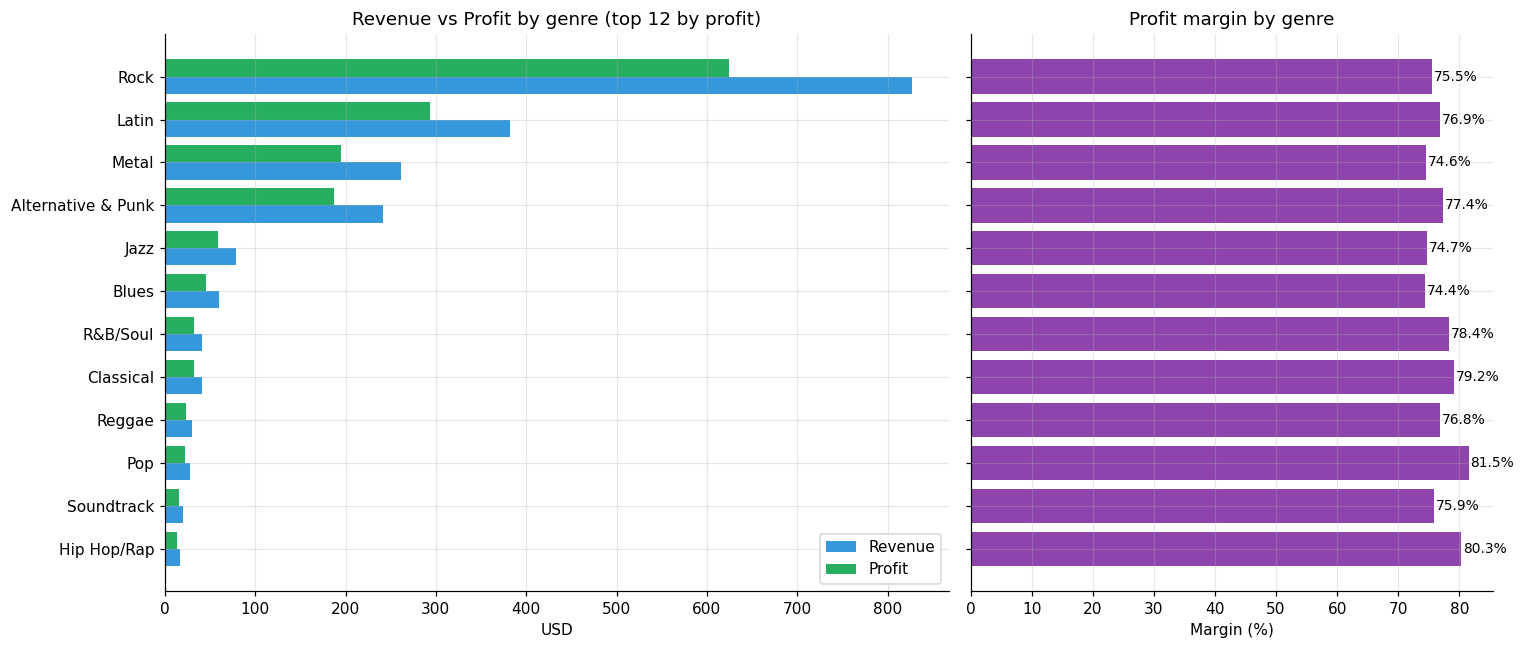

In [22]:
top_genres = genre_summary.head(12).sort_values("Revenue")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [3, 2]})

y = np.arange(len(top_genres))
h = 0.4
ax1.barh(y - h / 2, top_genres["Revenue"], h, label="Revenue", color="#3498DB")
ax1.barh(y + h / 2, top_genres["Profit"], h, label="Profit", color="#27AE60")
ax1.set_yticks(y)
ax1.set_yticklabels(top_genres["GenreName"])
ax1.set_xlabel("USD")
ax1.set_title("Revenue vs Profit by genre (top 12 by profit)")
ax1.legend(loc="lower right")

ax2.barh(y, top_genres["Margin"] * 100, color="#8E44AD")
ax2.set_yticks(y)
ax2.set_yticklabels([])
ax2.set_xlabel("Margin (%)")
ax2.set_title("Profit margin by genre")
for i, m in enumerate(top_genres["Margin"]):
    ax2.text(m * 100 + 0.3, i, f"{m * 100:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [23]:
artist_summary = summarize(sales_cost_master, "ArtistName")
album_summary = summarize(sales_cost_master, "AlbumTitle")

print(f"Artists with sales: {len(artist_summary)}   Albums with sales: {len(album_summary)}")
print("\nTop 15 artists by profit:")
display(artist_summary.head(15).round(2))
print("\nTop 10 albums by profit:")
display(album_summary.head(10).round(2))

Artists with sales: 165   Albums with sales: 304

Top 15 artists by profit:


,ArtistName,Revenue,EstimatedCost,Profit,UnitsSold,Lines,Margin
0,Iron Maiden,138.60,36.35,102.25,140,140,0.74
1,U2,105.93,22.88,83.05,107,107,0.78
2,Metallica,90.09,25.03,65.06,91,91,0.72
3,Led Zeppelin,86.13,24.02,62.11,87,87,0.72
4,Os Paralamas Do Sucesso,44.55,9.93,34.62,45,45,0.78
5,Faith No More,41.58,10.24,31.34,42,42,0.75
6,Deep Purple,43.56,12.48,31.08,44,44,0.71
7,R.E.M.,38.61,9.03,29.58,39,39,0.77
8,Eric Clapton,39.60,10.23,29.37,40,40,0.74
9,Creedence Clearwater Revival,36.63,8.37,28.26,37,37,0.77



Top 10 albums by profit:


,AlbumTitle,Revenue,EstimatedCost,Profit,UnitsSold,Lines,Margin
0,Minha Historia,26.73,6.19,20.54,27,27,0.77
1,Greatest Hits,25.74,6.10,19.64,26,26,0.76
2,Unplugged,24.75,6.36,18.39,25,25,0.74
3,Acústico,21.78,3.99,17.79,22,22,0.82
4,Greatest Kiss,19.80,4.55,15.25,20,20,0.77
5,My Generation - The Very Best Of The Who,18.81,4.07,14.74,19,19,0.78
6,Prenda Minha,18.81,4.16,14.65,19,19,0.78
7,"Chronicle, Vol. 2",18.81,4.45,14.36,19,19,0.76
8,International Superhits,17.82,3.62,14.20,18,18,0.80
9,"Chronicle, Vol. 1",17.82,3.93,13.89,18,18,0.78


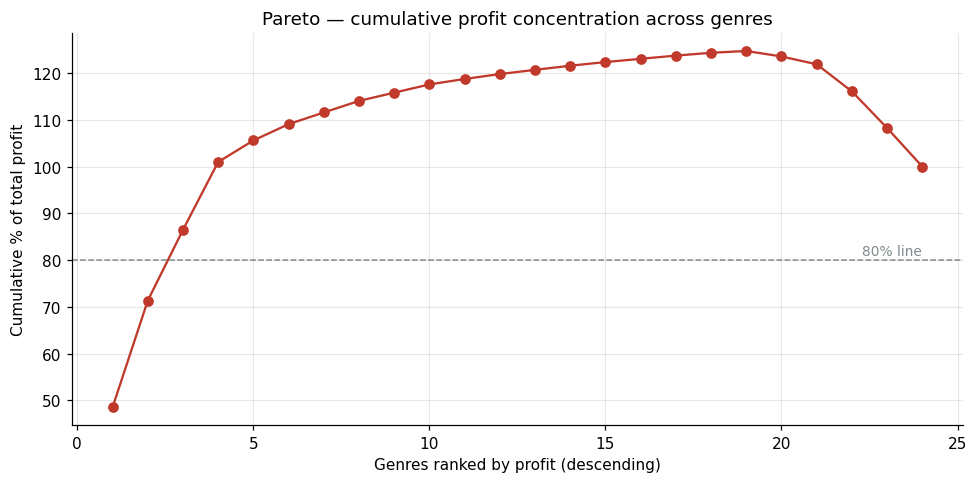

,dimension,population,profit_share_top10
0,Genre,24,117.6%
1,Artist,165,38.6%
2,Album,304,12.7%


In [24]:
def pareto_share(summary, k=10):
    total = summary["Profit"].sum()
    return summary.head(k)["Profit"].sum() / total

pareto = pd.DataFrame(
    {
        "dimension": ["Genre", "Artist", "Album"],
        "population": [len(genre_summary), len(artist_summary), len(album_summary)],
        "profit_share_top10": [
            pareto_share(genre_summary),
            pareto_share(artist_summary),
            pareto_share(album_summary),
        ],
    }
)
pareto["profit_share_top10"] = pareto["profit_share_top10"].map(pct)

fig, ax = plt.subplots(figsize=(9, 4.5))
gs = genre_summary.copy()
gs["CumProfitShare"] = gs["Profit"].cumsum() / gs["Profit"].sum()
ax.plot(range(1, len(gs) + 1), gs["CumProfitShare"] * 100, marker="o", color="#C0392B")
ax.axhline(80, ls="--", color="#7F8C8D", lw=1)
ax.set_xlabel("Genres ranked by profit (descending)")
ax.set_ylabel("Cumulative % of total profit")
ax.set_title("Pareto — cumulative profit concentration across genres")
ax.text(len(gs), 81, "80% line", color="#7F8C8D", fontsize=9, ha="right")
plt.tight_layout()
plt.show()

pareto

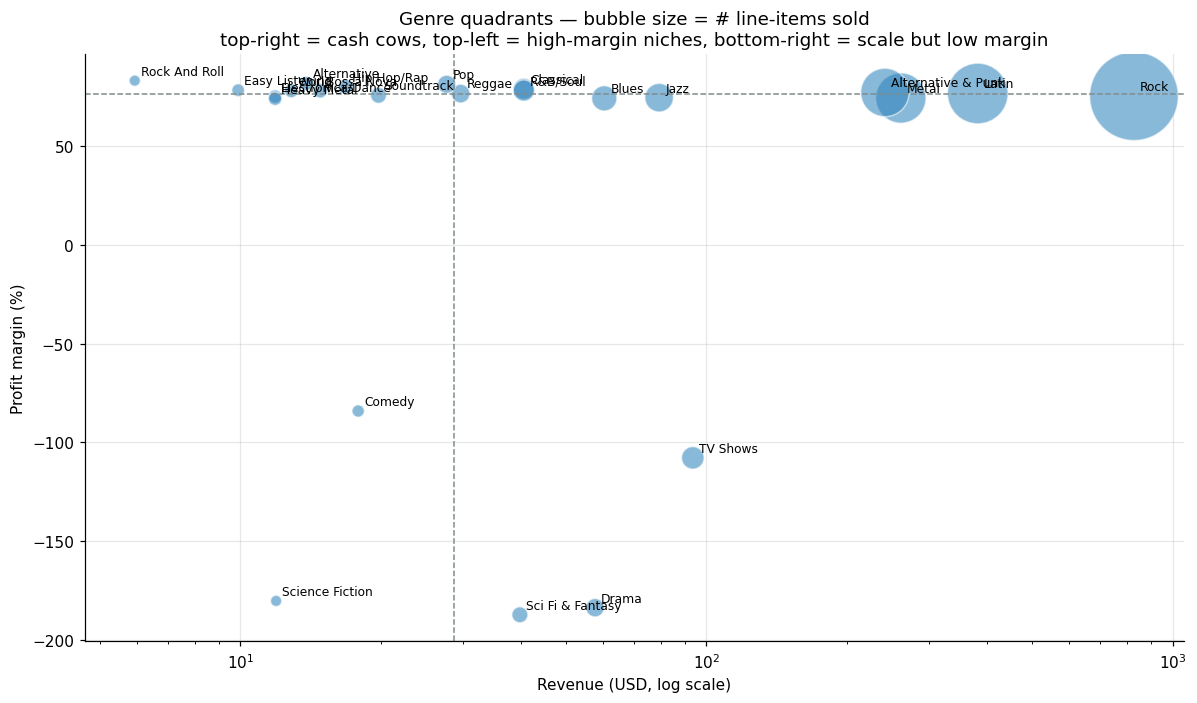

HIGH REVENUE / LOW MARGIN (scale, thin per-unit):


,GenreName,Revenue,Profit,Margin
0,Rock,826.65,624.182,0.755
2,Metal,261.36,194.877,0.746
4,Jazz,79.20,59.190,0.747
5,Blues,60.39,44.931,0.744
21,Sci Fi & Fantasy,39.80,-74.598,-1.874
22,TV Shows,93.53,-100.889,-1.079
23,Drama,57.71,-106.090,-1.838



HIGH MARGIN / NICHE (small volume, healthy per-unit):


,GenreName,Revenue,Profit,Margin
9,Pop,27.72,22.594,0.815
11,Hip Hop/Rap,16.83,13.511,0.803
12,Bossa Nova,14.85,11.615,0.782
13,Alternative,13.86,11.356,0.819
14,World,12.87,10.066,0.782
17,Easy Listening,9.90,7.774,0.785
18,Rock And Roll,5.94,4.952,0.834


In [25]:
rev_med = genre_summary["Revenue"].median()
mgn_med = genre_summary["Margin"].median()

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.scatter(
    genre_summary["Revenue"],
    genre_summary["Margin"] * 100,
    s=genre_summary["Lines"] * 4 + 30,
    alpha=0.55,
    color="#2980B9",
    edgecolor="white",
    linewidth=1,
)
ax.axvline(rev_med, ls="--", color="#7F8C8D", lw=1)
ax.axhline(mgn_med * 100, ls="--", color="#7F8C8D", lw=1)
ax.set_xscale("log")
ax.set_xlabel("Revenue (USD, log scale)")
ax.set_ylabel("Profit margin (%)")
ax.set_title(
    "Genre quadrants — bubble size = # line-items sold\n"
    "top-right = cash cows, top-left = high-margin niches, bottom-right = scale but low margin"
)

for _, row in genre_summary.iterrows():
    ax.annotate(
        row["GenreName"],
        (row["Revenue"], row["Margin"] * 100),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

hi_rev_lo_margin = genre_summary.query("Revenue > @rev_med and Margin < @mgn_med")[
    ["GenreName", "Revenue", "Profit", "Margin"]
]
hi_margin_niche = genre_summary.query("Revenue <= @rev_med and Margin > @mgn_med")[
    ["GenreName", "Revenue", "Profit", "Margin"]
]

print("HIGH REVENUE / LOW MARGIN (scale, thin per-unit):")
display(hi_rev_lo_margin.round(3))
print("\nHIGH MARGIN / NICHE (small volume, healthy per-unit):")
display(hi_margin_niche.round(3))

### 5.2 By customer & country

Who spends the most and who is most profitable to serve? Because overhead is allocated proportionally to revenue, per-customer margins are almost identical — the interesting cost signal shows up **between countries** (larger files, longer tracks → higher variable cost).

In [26]:
customer_name = (
    customers.assign(CustomerName=customers["FirstName"] + " " + customers["LastName"])
    [["CustomerId", "CustomerName"]]
)

customer_summary = (
    sales_cost_master.groupby(["CustomerId", "Country"], as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        EstimatedCost=("EstimatedCost", "sum"),
        Profit=("Profit", "sum"),
        Invoices=("InvoiceId", "nunique"),
        Lines=("InvoiceLineId", "count"),
    )
    .merge(customer_name, on="CustomerId")
)
customer_summary["Margin"] = customer_summary["Profit"] / customer_summary["Revenue"]
customer_summary = customer_summary[
    ["CustomerId", "CustomerName", "Country", "Invoices", "Lines", "Revenue", "EstimatedCost", "Profit", "Margin"]
].sort_values("Profit", ascending=False).reset_index(drop=True)

print("Top 10 most profitable customers:")
display(customer_summary.head(10).round(3))
print("\nBottom 10 least profitable customers:")
display(customer_summary.tail(10).round(3))

Top 10 most profitable customers:


,CustomerId,CustomerName,Country,Invoices,Lines,Revenue,EstimatedCost,Profit,Margin
0,47,Lucas Mancini,Italy,7,38,37.62,8.092,29.528,0.785
1,11,Alexandre Rocha,Brazil,7,38,37.62,8.251,29.369,0.781
2,23,John Gordon,USA,7,38,37.62,8.295,29.325,0.780
3,56,Diego Gutiérrez,Argentina,7,38,37.62,8.352,29.268,0.778
4,54,Steve Murray,United Kingdom,7,38,37.62,8.369,29.251,0.778
5,12,Roberto Almeida,Brazil,7,38,37.62,8.580,29.040,0.772
6,50,Enrique Muñoz,Spain,7,38,37.62,8.651,28.969,0.770
7,33,Ellie Sullivan,Canada,7,38,37.62,8.730,28.890,0.768
8,30,Edward Francis,Canada,7,38,37.62,8.779,28.841,0.767
9,16,Frank Harris,USA,7,38,37.62,8.817,28.803,0.766



Bottom 10 least profitable customers:


,CustomerId,CustomerName,Country,Invoices,Lines,Revenue,EstimatedCost,Profit,Margin
49,48,Johannes Van der Berg,Netherlands,7,38,40.62,25.172,15.448,0.380
50,24,Frank Ralston,USA,7,38,43.62,29.335,14.285,0.327
51,44,Terhi Hämäläinen,Finland,7,38,41.62,31.826,9.794,0.235
52,45,Ladislav Kovács,Hungary,7,38,45.62,37.595,8.025,0.176
53,28,Julia Barnett,USA,7,38,43.62,39.067,4.553,0.104
54,37,Fynn Zimmermann,Germany,7,38,43.62,40.208,3.412,0.078
55,46,Hugh O'Reilly,Ireland,7,38,45.62,47.582,-1.962,-0.043
56,57,Luis Rojas,Chile,7,38,46.62,54.361,-7.741,-0.166
57,26,Richard Cunningham,USA,7,38,47.62,58.221,-10.601,-0.223
58,6,Helena Holý,Czech Republic,7,38,49.62,60.446,-10.826,-0.218


In [27]:
country_summary = (
    sales_cost_master.groupby("Country", as_index=False)
    .agg(
        Customers=("CustomerId", "nunique"),
        Invoices=("InvoiceId", "nunique"),
        Lines=("InvoiceLineId", "count"),
        Revenue=("Revenue", "sum"),
        EstimatedCost=("EstimatedCost", "sum"),
        Profit=("Profit", "sum"),
    )
)
country_summary["Margin"] = country_summary["Profit"] / country_summary["Revenue"]
country_summary["RevPerInvoice"] = country_summary["Revenue"] / country_summary["Invoices"]
country_summary["ProfitPerInvoice"] = country_summary["Profit"] / country_summary["Invoices"]
country_summary = country_summary.sort_values("Revenue", ascending=False).reset_index(drop=True)

country_summary.round(3)

,Country,Customers,Invoices,Lines,Revenue,EstimatedCost,Profit,Margin,RevPerInvoice,ProfitPerInvoice
0,USA,13,91,494,523.06,258.071,264.989,0.507,5.748,2.912
1,Canada,8,56,304,303.96,87.454,216.506,0.712,5.428,3.866
2,France,5,35,190,195.10,87.200,107.900,0.553,5.574,3.083
3,Brazil,5,35,190,190.10,54.570,135.530,0.713,5.431,3.872
4,Germany,4,28,152,156.48,67.791,88.689,0.567,5.589,3.167
5,United Kingdom,3,21,114,112.86,26.858,86.002,0.762,5.374,4.095
6,Czech Republic,2,14,76,90.24,79.745,10.495,0.116,6.446,0.750
7,Portugal,2,14,76,77.24,28.663,48.577,0.629,5.517,3.470
8,India,2,13,74,75.26,26.551,48.709,0.647,5.789,3.747
9,Chile,1,7,38,46.62,54.361,-7.741,-0.166,6.660,-1.106


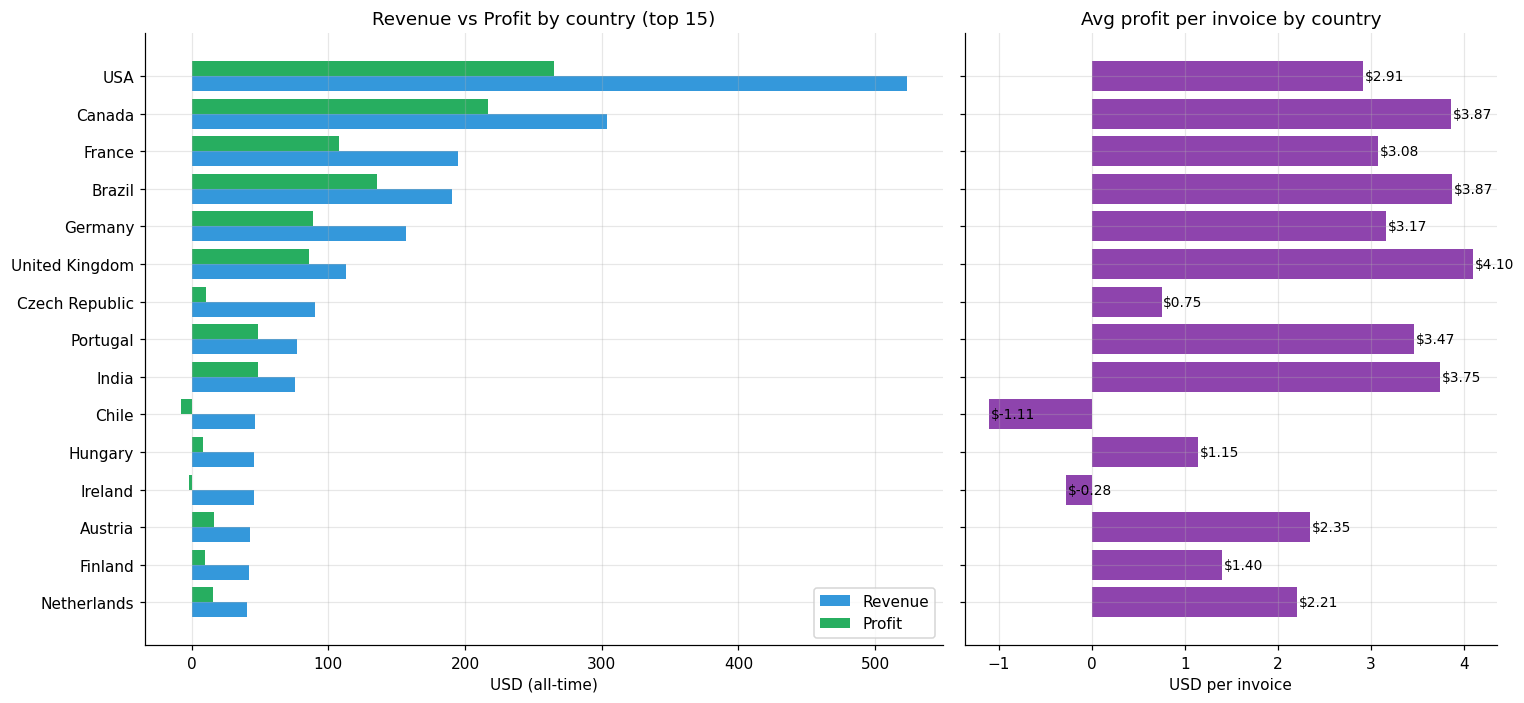

In [28]:
top_c = country_summary.head(15).sort_values("Revenue")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5), gridspec_kw={"width_ratios": [3, 2]})

y = np.arange(len(top_c))
h = 0.4
ax1.barh(y - h / 2, top_c["Revenue"], h, label="Revenue", color="#3498DB")
ax1.barh(y + h / 2, top_c["Profit"], h, label="Profit", color="#27AE60")
ax1.set_yticks(y)
ax1.set_yticklabels(top_c["Country"])
ax1.set_xlabel("USD (all-time)")
ax1.set_title("Revenue vs Profit by country (top 15)")
ax1.legend(loc="lower right")

ax2.barh(y, top_c["ProfitPerInvoice"], color="#8E44AD")
ax2.set_yticks(y)
ax2.set_yticklabels([])
ax2.set_xlabel("USD per invoice")
ax2.set_title("Avg profit per invoice by country")
for i, v in enumerate(top_c["ProfitPerInvoice"]):
    ax2.text(v + 0.02, i, f"${v:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [29]:
country_cost_mix = (
    sales_cost_master.groupby("Country", as_index=False)
    .agg(
        Lines=("InvoiceLineId", "count"),
        AvgMinutes=("Minutes", "mean"),
        AvgMegabytes=("Megabytes", "mean"),
        AvgVariableCostPerLine=("EstimatedCost", "mean"),
    )
    .sort_values("AvgMegabytes", ascending=False)
    .reset_index(drop=True)
)

print("Do some countries buy heavier / longer tracks?")
display(country_cost_mix.round(3).head(10))
print("\nLightest-file buyers:")
display(country_cost_mix.round(3).tail(10))

Do some countries buy heavier / longer tracks?


,Country,Lines,AvgMinutes,AvgMegabytes,AvgVariableCostPerLine
0,Chile,38,13.827,120.854,1.431
1,Ireland,38,12.547,105.395,1.252
2,Czech Republic,76,11.571,85.236,1.049
3,Hungary,38,10.019,79.933,0.989
4,Finland,38,9.350,65.530,0.838
5,Austria,38,9.868,51.136,0.689
6,Netherlands,38,8.028,48.824,0.662
7,Sweden,38,6.440,35.233,0.513
8,USA,494,6.635,35.213,0.522
9,Norway,38,7.053,34.516,0.505



Lightest-file buyers:


,Country,Lines,AvgMinutes,AvgMegabytes,AvgVariableCostPerLine
14,Canada,304,4.732,13.292,0.288
15,Brazil,190,4.638,13.231,0.287
16,Australia,38,5.317,10.122,0.257
17,Poland,38,4.715,9.170,0.243
18,Belgium,38,4.458,8.776,0.261
19,United Kingdom,114,4.442,8.233,0.236
20,Denmark,38,4.536,8.179,0.244
21,Spain,38,4.241,7.989,0.228
22,Argentina,38,3.946,7.564,0.220
23,Italy,38,3.632,6.961,0.213


### 5.3 By media type & track characteristics

Track duration and file size are the two levers driving variable cost. This block converts them into per-minute / per-MB economics and checks whether longer tracks are actually less profitable.

In [30]:
media_summary = (
    sales_cost_master.assign(
        SoldMinutes=lambda d: d["Minutes"] * d["Quantity"],
        SoldMegabytes=lambda d: d["Megabytes"] * d["Quantity"],
    )
    .groupby("MediaTypeName", as_index=False)
    .agg(
        Lines=("InvoiceLineId", "count"),
        Revenue=("Revenue", "sum"),
        EstimatedCost=("EstimatedCost", "sum"),
        Profit=("Profit", "sum"),
        SoldMinutes=("SoldMinutes", "sum"),
        SoldMegabytes=("SoldMegabytes", "sum"),
    )
)
media_summary["Margin"] = media_summary["Profit"] / media_summary["Revenue"]
media_summary["RevPerMinute"] = media_summary["Revenue"] / media_summary["SoldMinutes"]
media_summary["CostPerMinute"] = media_summary["EstimatedCost"] / media_summary["SoldMinutes"]
media_summary["ProfitPerMinute"] = media_summary["Profit"] / media_summary["SoldMinutes"]
media_summary["RevPerMB"] = media_summary["Revenue"] / media_summary["SoldMegabytes"]
media_summary["CostPerMB"] = media_summary["EstimatedCost"] / media_summary["SoldMegabytes"]
media_summary["ProfitPerMB"] = media_summary["Profit"] / media_summary["SoldMegabytes"]

media_summary.sort_values("Profit", ascending=False).round(4)

,MediaTypeName,Lines,Revenue,EstimatedCost,Profit,SoldMinutes,SoldMegabytes,Margin,RevPerMinute,CostPerMinute,ProfitPerMinute,RevPerMB,CostPerMB,ProfitPerMB
1,MPEG audio file,1976,1956.24,472.4768,1483.7632,8734.9381,17041.8321,0.7585,0.2240,0.0541,0.1699,0.1148,0.0277,0.0871
2,Protected AAC audio file,146,144.54,28.6020,115.9380,723.6247,718.1626,0.8021,0.1997,0.0395,0.1602,0.2013,0.0398,0.1614
4,Purchased AAC audio file,4,3.96,0.9055,3.0545,16.6231,32.9888,0.7713,0.2382,0.0545,0.1837,0.1200,0.0274,0.0926
0,AAC audio file,3,2.97,0.4861,2.4839,10.9745,10.6315,0.8363,0.2706,0.0443,0.2263,0.2794,0.0457,0.2336
3,Protected MPEG-4 video file,111,220.89,539.0713,-318.1813,4530.1165,49342.4124,-1.4405,0.0488,0.1190,-0.0702,0.0045,0.0109,-0.0064


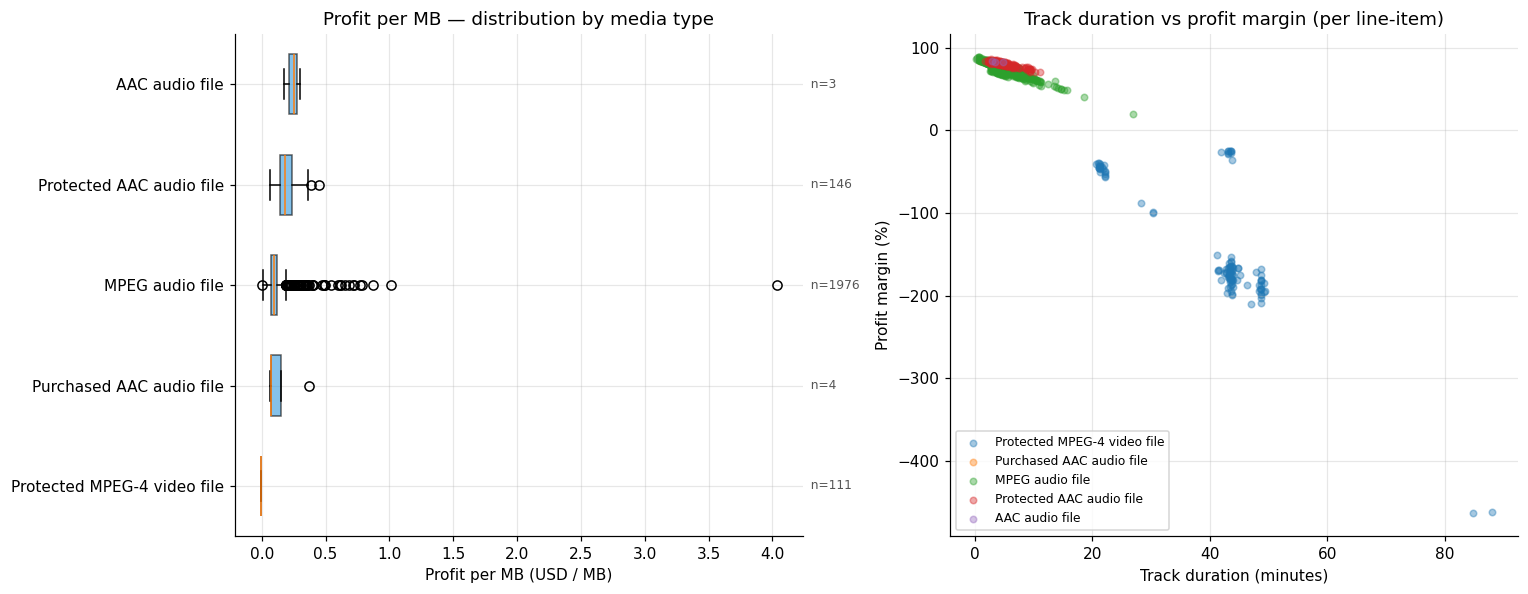

In [31]:
per_line = sales_cost_master.assign(
    ProfitPerMB=lambda d: d["Profit"] / d["Megabytes"],
    ProfitPerMinute=lambda d: d["Profit"] / d["Minutes"],
)

media_order = (
    per_line.groupby("MediaTypeName")["ProfitPerMB"].median().sort_values().index.tolist()
)
groups = [per_line.loc[per_line["MediaTypeName"] == m, "ProfitPerMB"].values for m in media_order]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

bp = ax1.boxplot(groups, vert=False, patch_artist=True, labels=media_order, widths=0.6)
for patch in bp["boxes"]:
    patch.set_facecolor("#3498DB")
    patch.set_alpha(0.6)
ax1.set_xlabel("Profit per MB (USD / MB)")
ax1.set_title("Profit per MB — distribution by media type")

ax1_lines = per_line.groupby("MediaTypeName").size().reindex(media_order)
for i, n in enumerate(ax1_lines):
    ax1.text(ax1.get_xlim()[1], i + 1, f"  n={n}", va="center", fontsize=8, color="#555")

for mt in media_order:
    sub = per_line[per_line["MediaTypeName"] == mt]
    ax2.scatter(sub["Minutes"], sub["Margin"] * 100, alpha=0.4, s=18, label=mt)
ax2.set_xlabel("Track duration (minutes)")
ax2.set_ylabel("Profit margin (%)")
ax2.set_title("Track duration vs profit margin (per line-item)")
ax2.legend(fontsize=8, loc="lower left")

plt.tight_layout()
plt.show()

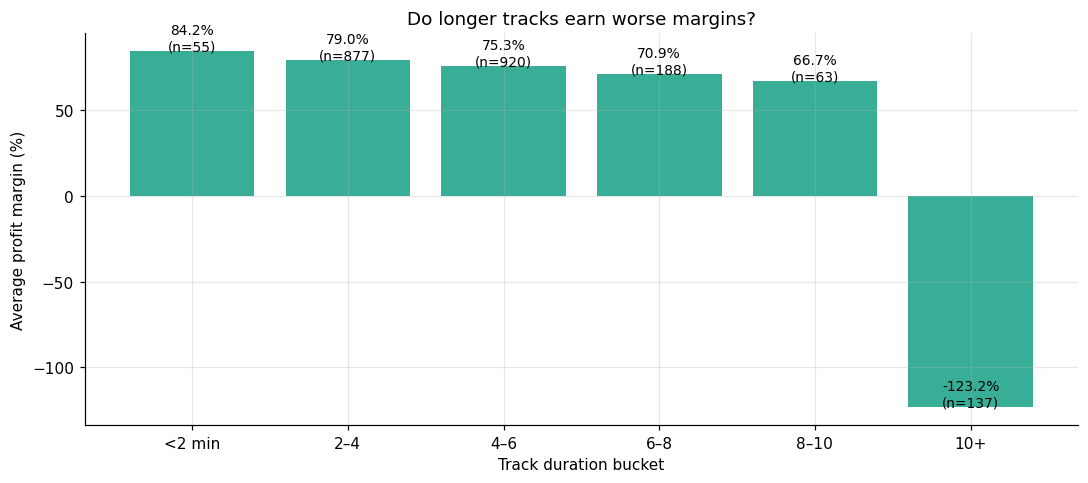

,Lines,AvgMegabytes,Revenue,EstimatedCost,Profit,Margin
DurationBucket,,,,,,
<2 min,55,2.523,54.45,8.587,45.863,0.842
2–4,877,6.179,868.23,182.561,685.669,0.790
4–6,920,9.025,910.80,224.895,685.905,0.753
6–8,188,12.331,186.12,54.231,131.889,0.709
8–10,63,15.711,62.37,20.755,41.615,0.667
10+,137,364.797,246.63,550.512,-303.882,-1.232


In [32]:
bins = [0, 2, 4, 6, 8, 10, np.inf]
labels = ["<2 min", "2–4", "4–6", "6–8", "8–10", "10+"]

by_bucket = (
    sales_cost_master.assign(
        DurationBucket=pd.cut(sales_cost_master["Minutes"], bins=bins, labels=labels, right=False)
    )
    .groupby("DurationBucket", observed=True)
    .agg(
        Lines=("InvoiceLineId", "count"),
        AvgMegabytes=("Megabytes", "mean"),
        Revenue=("Revenue", "sum"),
        EstimatedCost=("EstimatedCost", "sum"),
        Profit=("Profit", "sum"),
    )
)
by_bucket["Margin"] = by_bucket["Profit"] / by_bucket["Revenue"]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(by_bucket.index.astype(str), by_bucket["Margin"] * 100, color="#16A085", alpha=0.85)
ax.set_ylabel("Average profit margin (%)")
ax.set_xlabel("Track duration bucket")
ax.set_title("Do longer tracks earn worse margins?")
for i, (m, n) in enumerate(zip(by_bucket["Margin"], by_bucket["Lines"])):
    ax.text(i, m * 100 + 0.4, f"{m * 100:.1f}%\n(n={n})", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

by_bucket.round(3)

## Time-based trends

Chinook's invoices span 60 months (5 full years), so there's plenty of runway for temporal analysis. This section covers:

- **Monthly trend** — absolute revenue / cost / profit and month-over-month growth.
- **Seasonality** — average behavior for each calendar month across all years.
- **Genre mix over time** — stacked area of each genre's share of monthly revenue.
- **Customer recency** — days since each customer's last purchase, relative to the latest invoice date in the dataset.

In [33]:
monthly = (
    sales_cost_master.assign(
        Month=sales_cost_master["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
    )
    .groupby("Month", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        EstimatedCost=("EstimatedCost", "sum"),
        Profit=("Profit", "sum"),
        Invoices=("InvoiceId", "nunique"),
        Lines=("InvoiceLineId", "count"),
    )
)
monthly["Margin"] = monthly["Profit"] / monthly["Revenue"]
monthly["RevenueMoM"] = monthly["Revenue"].pct_change()
monthly["ProfitMoM"] = monthly["Profit"].pct_change()

date_min = sales_cost_master["InvoiceDate"].min().date()
date_max = sales_cost_master["InvoiceDate"].max().date()
print(f"Date range: {date_min} → {date_max}   ({len(monthly)} months)")

monthly.head()

Date range: 2021-01-01 → 2025-12-22   (60 months)


,Month,Revenue,EstimatedCost,Profit,Invoices,Lines,Margin,RevenueMoM,ProfitMoM
0,2021-01-01,35.64,8.669685,26.970315,6,36,0.756743,NaN,NaN
1,2021-02-01,37.62,8.591583,29.028417,7,38,0.771622,0.055556,0.076310
2,2021-03-01,37.62,8.966557,28.653443,7,38,0.761655,0.000000,-0.012917
3,2021-04-01,37.62,9.366104,28.253896,7,38,0.751034,0.000000,-0.013944
4,2021-05-01,37.62,8.857122,28.762878,7,38,0.764563,0.000000,0.018015


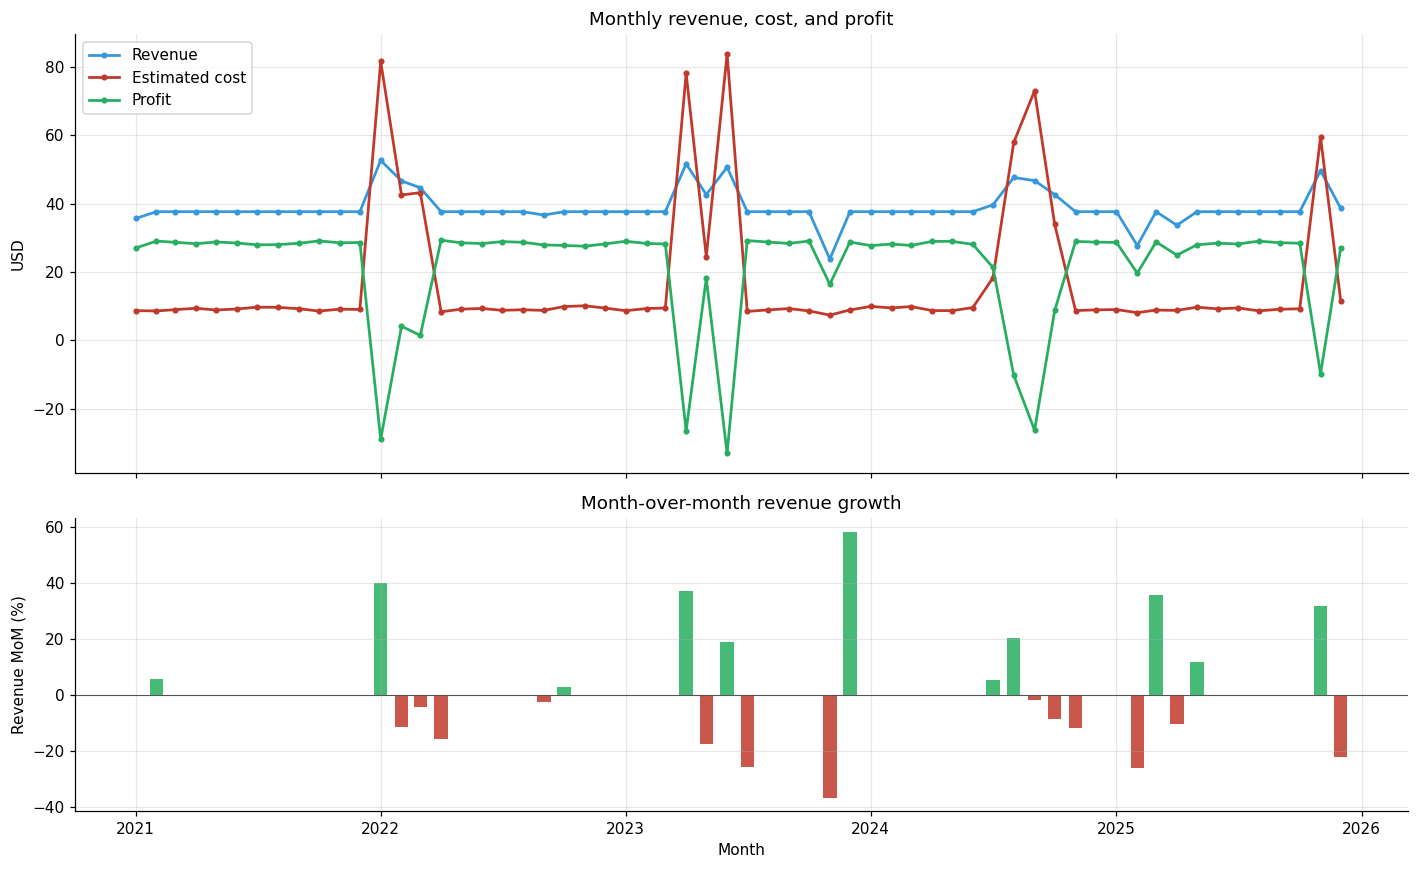

,mean_MoM,std_MoM
RevenueMoM,1.2%,15.4%
ProfitMoM,5.9%,272.4%


In [34]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True, gridspec_kw={"height_ratios": [3, 2]})

ax1.plot(monthly["Month"], monthly["Revenue"], label="Revenue", color="#3498DB", lw=1.8, marker="o", ms=3)
ax1.plot(monthly["Month"], monthly["EstimatedCost"], label="Estimated cost", color="#C0392B", lw=1.8, marker="o", ms=3)
ax1.plot(monthly["Month"], monthly["Profit"], label="Profit", color="#27AE60", lw=1.8, marker="o", ms=3)
ax1.set_ylabel("USD")
ax1.set_title("Monthly revenue, cost, and profit")
ax1.legend(loc="upper left")

mom = monthly["RevenueMoM"] * 100
colors = ["#27AE60" if x >= 0 else "#C0392B" for x in mom.fillna(0)]
ax2.bar(monthly["Month"], mom, color=colors, width=20, alpha=0.85)
ax2.axhline(0, color="#555", lw=0.7)
ax2.set_ylabel("Revenue MoM (%)")
ax2.set_xlabel("Month")
ax2.set_title("Month-over-month revenue growth")

plt.tight_layout()
plt.show()

vol = monthly[["RevenueMoM", "ProfitMoM"]].agg(["mean", "std"]).T
vol.columns = ["mean_MoM", "std_MoM"]
vol.apply(lambda s: s.map(pct))

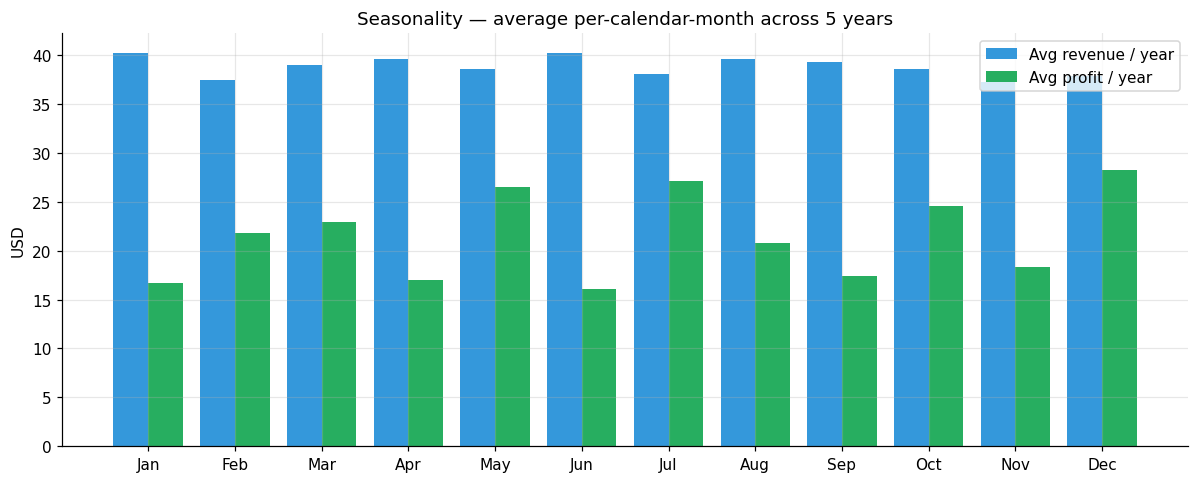

,CalMonth,Revenue,Profit,Invoices,AvgRevPerYear,AvgProfitPerYear
0,1,201.12,83.29,34,40.22,16.66
1,2,187.20,109.27,33,37.44,21.85
2,3,195.10,114.78,35,39.02,22.96
3,4,198.14,84.89,33,39.63,16.98
4,5,193.10,132.33,35,38.62,26.47
5,6,201.10,80.16,35,40.22,16.03
6,7,190.10,135.45,35,38.02,27.09
7,8,198.10,104.14,35,39.62,20.83
8,9,196.20,86.88,33,39.24,17.38
9,10,193.10,122.98,35,38.62,24.60


In [35]:
years_span = sales_cost_master["InvoiceDate"].dt.year.nunique()

seasonal = (
    sales_cost_master.assign(CalMonth=sales_cost_master["InvoiceDate"].dt.month)
    .groupby("CalMonth", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Profit=("Profit", "sum"),
        Invoices=("InvoiceId", "nunique"),
    )
)
seasonal["AvgRevPerYear"] = seasonal["Revenue"] / years_span
seasonal["AvgProfitPerYear"] = seasonal["Profit"] / years_span
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(12)
w = 0.4
ax.bar(x - w / 2, seasonal["AvgRevPerYear"], w, label="Avg revenue / year", color="#3498DB")
ax.bar(x + w / 2, seasonal["AvgProfitPerYear"], w, label="Avg profit / year", color="#27AE60")
ax.set_xticks(x)
ax.set_xticklabels(month_names)
ax.set_ylabel("USD")
ax.set_title(f"Seasonality — average per-calendar-month across {years_span} years")
ax.legend()
plt.tight_layout()
plt.show()

seasonal.round(2)

### Genre mix over time

Has the genre composition of revenue shifted over the 60 months? Stack the top 8 genres by lifetime revenue as % of that month's revenue; everything else is bucketed into `Other`.

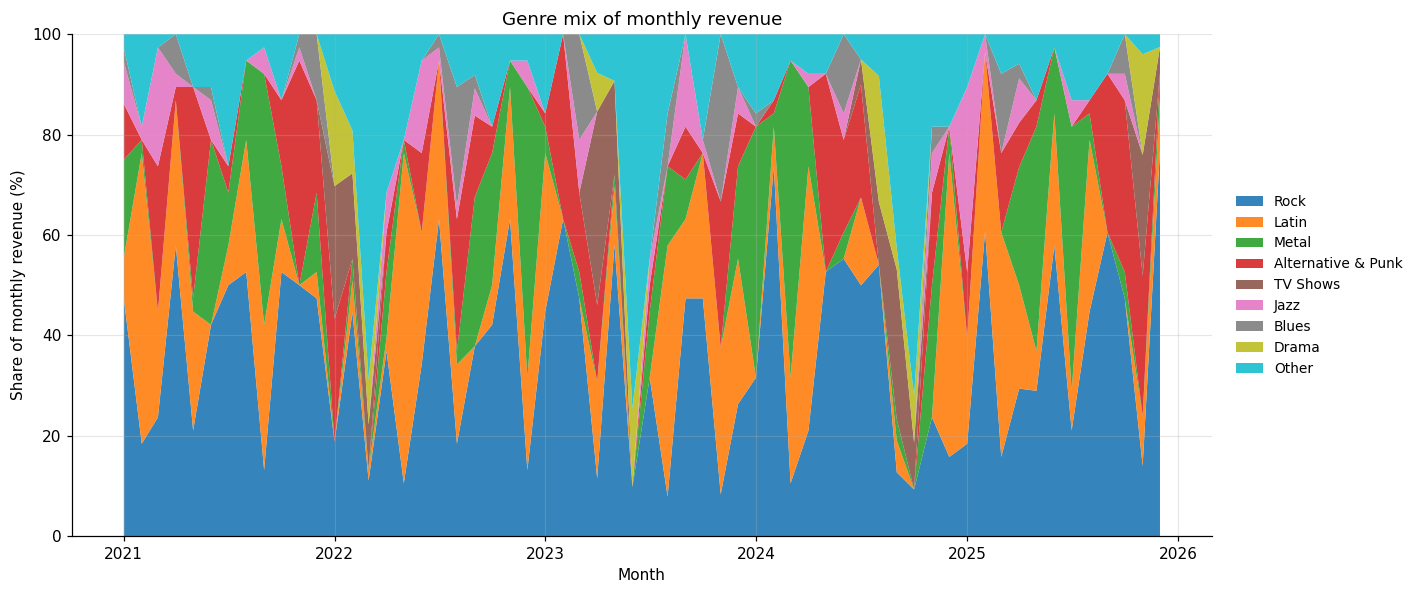

,avg_share_year1_%,avg_share_last_year_%,delta_pp
GenreName,,,
TV Shows,0.00,2.43,2.43
Alternative & Punk,13.86,11.62,-2.24
Drama,0.00,1.67,1.67
Metal,13.68,12.48,-1.20
Other,7.69,6.74,-0.95
Jazz,4.42,4.98,0.56
Blues,2.42,2.22,-0.20
Rock,39.68,39.64,-0.04
Latin,18.24,18.22,-0.02


In [36]:
genre_month = (
    sales_cost_master.assign(
        Month=sales_cost_master["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
    )
    .groupby(["Month", "GenreName"])["Revenue"]
    .sum()
    .unstack("GenreName", fill_value=0.0)
)

top_g = genre_month.sum().sort_values(ascending=False).head(8).index.tolist()
other_cols = [c for c in genre_month.columns if c not in top_g]
mix = genre_month[top_g].copy()
mix["Other"] = genre_month[other_cols].sum(axis=1)

share = mix.div(mix.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 5.5))
palette = plt.cm.tab10(np.linspace(0, 1, share.shape[1]))
ax.stackplot(share.index, share.T.values, labels=share.columns.tolist(), colors=palette, alpha=0.9)
ax.set_ylabel("Share of monthly revenue (%)")
ax.set_xlabel("Month")
ax.set_title("Genre mix of monthly revenue")
ax.set_ylim(0, 100)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

first_year = share.iloc[:12].mean().sort_values(ascending=False)
last_year = share.iloc[-12:].mean().sort_values(ascending=False)
mix_shift = pd.DataFrame(
    {
        "avg_share_year1_%": first_year.round(2),
        "avg_share_last_year_%": last_year.reindex(first_year.index).round(2),
    }
)
mix_shift["delta_pp"] = (mix_shift["avg_share_last_year_%"] - mix_shift["avg_share_year1_%"]).round(2)
mix_shift.sort_values("delta_pp", key=abs, ascending=False)

### Customer recency

For every customer, days since their most-recent invoice, measured against the latest date in the dataset. Useful for defining churn / win-back cohorts even though the dataset has finite coverage.

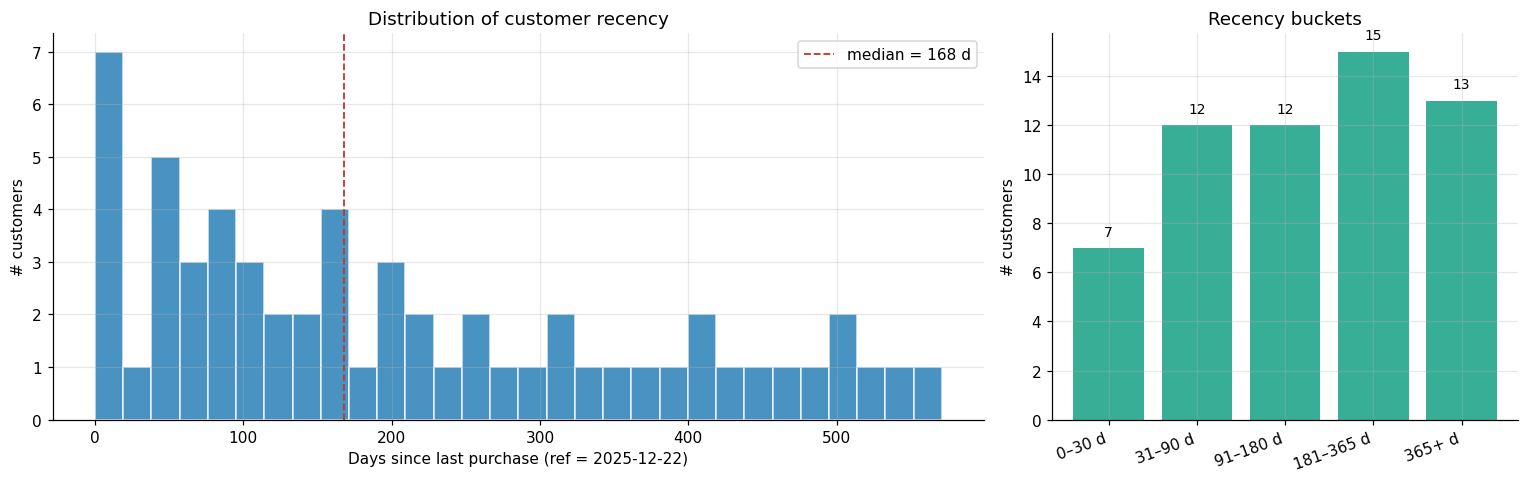

,Customers,LifetimeRevenue,LifetimeProfit
RecencyBucket,,,
0–30 d,7,273.34,168.38
31–90 d,12,477.44,251.25
91–180 d,12,475.44,270.79
181–365 d,15,597.30,310.17
365+ d,13,505.08,286.47


In [37]:
ref_date = sales_cost_master["InvoiceDate"].max()

recency = (
    sales_cost_master.groupby("CustomerId")
    .agg(
        LastPurchase=("InvoiceDate", "max"),
        FirstPurchase=("InvoiceDate", "min"),
        LifetimeRevenue=("Revenue", "sum"),
        LifetimeProfit=("Profit", "sum"),
    )
    .reset_index()
    .merge(customer_name, on="CustomerId")
)
recency["DaysSinceLast"] = (ref_date - recency["LastPurchase"]).dt.days

buckets = [-1, 30, 90, 180, 365, np.inf]
labels = ["0–30 d", "31–90 d", "91–180 d", "181–365 d", "365+ d"]
recency["RecencyBucket"] = pd.cut(recency["DaysSinceLast"], bins=buckets, labels=labels)

bucket_summary = (
    recency.groupby("RecencyBucket", observed=True)
    .agg(
        Customers=("CustomerId", "count"),
        LifetimeRevenue=("LifetimeRevenue", "sum"),
        LifetimeProfit=("LifetimeProfit", "sum"),
    )
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={"width_ratios": [2, 1]})

ax1.hist(recency["DaysSinceLast"], bins=30, color="#2980B9", alpha=0.85, edgecolor="white")
ax1.axvline(recency["DaysSinceLast"].median(), color="#C0392B", ls="--", lw=1.2, label=f"median = {recency['DaysSinceLast'].median():.0f} d")
ax1.set_xlabel(f"Days since last purchase (ref = {ref_date.date()})")
ax1.set_ylabel("# customers")
ax1.set_title("Distribution of customer recency")
ax1.legend()

ax2.bar(bucket_summary.index.astype(str), bucket_summary["Customers"], color="#16A085", alpha=0.85)
ax2.set_ylabel("# customers")
ax2.set_title("Recency buckets")
for i, n in enumerate(bucket_summary["Customers"]):
    ax2.text(i, n + 0.5, str(n), ha="center", fontsize=9)
plt.setp(ax2.get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
plt.show()

bucket_summary.round(2)

## Advanced analytics

Three modeling pieces built on `sales_cost_master`, each showcasing a different DS skill:

- **7.1 Cost-aware customer segmentation** — unsupervised K-Means over engineered per-customer features to discover behavioral clusters (high-value vs high-volume-low-margin, etc.).
- **7.2 Invoice-profit prediction** — supervised RandomForest regression at the invoice grain, with feature-importance interpretation.
- **7.3 Profit-first recommendations** — for each country, which genres to promote when ranked by *profit* rather than revenue.

### 7.1 Cost-aware customer segmentation

Engineer a small per-customer feature matrix, standardize, and cluster with K-Means. Features cover **spend, cost efficiency, and taste**:

| Feature | Meaning |
|---|---|
| `Revenue`, `Profit`, `Margin` | Lifetime value + efficiency |
| `AvgMinutes`, `AvgMegabytes` | Physical size of a typical purchased track (cost driver) |
| `GenreDiversity` | Number of distinct genres the customer has bought from |
| `TopGenreShare` | Share of revenue concentrated in the customer's #1 genre (higher = niche/loyal, lower = eclectic) |

In [38]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

base = sales_cost_master.groupby("CustomerId", as_index=False).agg(
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum"),
    AvgMinutes=("Minutes", "mean"),
    AvgMegabytes=("Megabytes", "mean"),
)
base["Margin"] = base["Profit"] / base["Revenue"]

cust_genre = sales_cost_master.groupby(["CustomerId", "GenreName"])["Revenue"].sum()
top_share = (
    cust_genre.groupby("CustomerId").apply(lambda s: s.max() / s.sum()).rename("TopGenreShare")
)
diversity = cust_genre.groupby("CustomerId").size().rename("GenreDiversity")

cust_features = (
    base.merge(top_share.reset_index(), on="CustomerId")
        .merge(diversity.reset_index(), on="CustomerId")
        .merge(customer_name, on="CustomerId")
)

FEATURES = ["Revenue", "Profit", "Margin", "AvgMinutes", "AvgMegabytes", "GenreDiversity", "TopGenreShare"]
print(f"cust_features: {cust_features.shape}")
cust_features[["CustomerName", *FEATURES]].head()

cust_features: (59, 9)


,CustomerName,Revenue,Profit,Margin,AvgMinutes,AvgMegabytes,GenreDiversity,TopGenreShare
0,Luís Gonçalves,39.62,20.154130,0.508686,6.477762,34.413780,8,0.349823
1,Leonie Köhler,37.62,28.342523,0.753390,4.192904,8.008406,7,0.447368
2,François Tremblay,39.62,20.607063,0.520118,6.481819,33.351552,10,0.249874
3,Bjørn Hansen,39.62,20.440968,0.515925,7.053229,34.516005,8,0.424785
4,František Wichterlová,40.62,21.321153,0.524893,6.592529,34.682821,8,0.365583


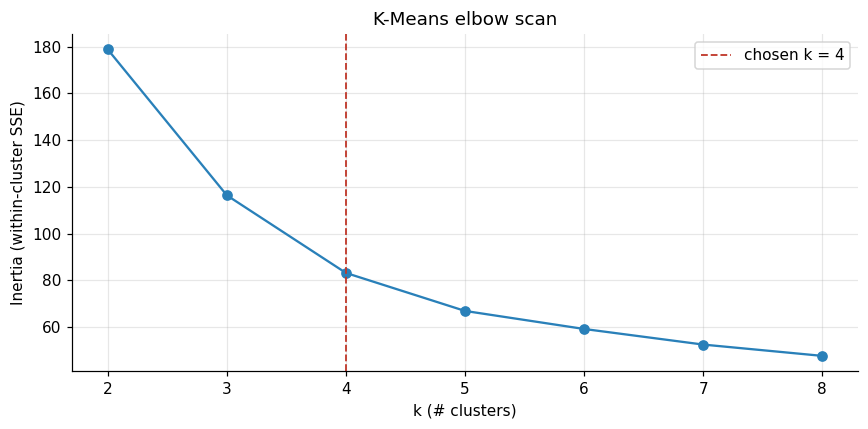

,Customers,Revenue,Profit,Margin,AvgMinutes,AvgMegabytes,GenreDiversity,TopGenreShare
Cluster,,,,,,,,
0,18,38.010,27.177,0.716,4.829,13.104,7.889,0.320
1,7,46.049,-2.163,-0.042,12.640,106.104,9.000,0.272
2,19,37.620,28.494,0.757,4.417,8.440,5.789,0.518
3,15,40.487,18.108,0.449,7.322,41.950,8.333,0.354


In [39]:
X = cust_features[FEATURES].values
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

ks = range(2, 9)
inertias = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(Xs)
    inertias.append(km.inertia_)

K_CHOSEN = 4
km_final = KMeans(n_clusters=K_CHOSEN, n_init=25, random_state=42)
cust_features["Cluster"] = km_final.fit_predict(Xs)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(ks), inertias, marker="o", color="#2980B9")
ax.axvline(K_CHOSEN, color="#C0392B", ls="--", lw=1.2, label=f"chosen k = {K_CHOSEN}")
ax.set_xlabel("k (# clusters)")
ax.set_ylabel("Inertia (within-cluster SSE)")
ax.set_title("K-Means elbow scan")
ax.legend()
plt.tight_layout()
plt.show()

cluster_profile = (
    cust_features.groupby("Cluster")
    .agg(
        Customers=("CustomerId", "count"),
        Revenue=("Revenue", "mean"),
        Profit=("Profit", "mean"),
        Margin=("Margin", "mean"),
        AvgMinutes=("AvgMinutes", "mean"),
        AvgMegabytes=("AvgMegabytes", "mean"),
        GenreDiversity=("GenreDiversity", "mean"),
        TopGenreShare=("TopGenreShare", "mean"),
    )
    .round(3)
)
cluster_profile

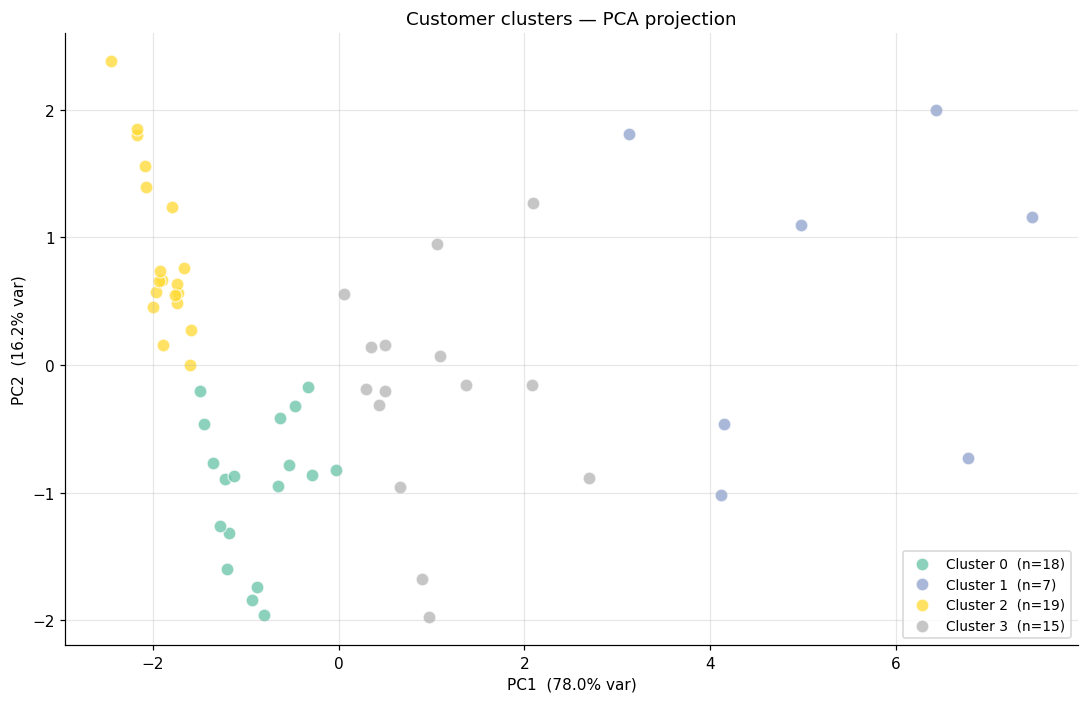

,Customers,Revenue,Profit,Margin,AvgMegabytes,TopGenreShare,Label
Cluster,,,,,,,
0,18,38.010,27.177,0.716,13.104,0.320,Steady audio buyers
1,7,46.049,-2.163,-0.042,106.104,0.272,High-cost buyers (video-heavy)
2,19,37.620,28.494,0.757,8.440,0.518,Steady audio buyers
3,15,40.487,18.108,0.449,41.950,0.354,Large-file audio buyers


In [40]:
pca = PCA(n_components=2, random_state=42)
XY = pca.fit_transform(Xs)

fig, ax = plt.subplots(figsize=(10, 6.5))
palette = plt.cm.Set2(np.linspace(0, 1, K_CHOSEN))
for c in range(K_CHOSEN):
    m = cust_features["Cluster"] == c
    ax.scatter(
        XY[m, 0], XY[m, 1],
        color=palette[c], s=70, alpha=0.75, edgecolor="white", linewidth=0.8,
        label=f"Cluster {c}  (n={m.sum()})",
    )
ax.set_xlabel(f"PC1  ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
ax.set_ylabel(f"PC2  ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")
ax.set_title("Customer clusters — PCA projection")
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

def label_cluster(row):
    if row["Margin"] < 0.4:
        return "High-cost buyers (video-heavy)"
    if row["Revenue"] >= cust_features["Revenue"].quantile(0.75) and row["Margin"] >= 0.7:
        return "High-value / high-margin"
    if row["AvgMegabytes"] >= cust_features["AvgMegabytes"].quantile(0.75):
        return "Large-file audio buyers"
    return "Steady audio buyers"

cluster_profile["Label"] = cluster_profile.apply(label_cluster, axis=1)
cluster_profile[["Customers", "Revenue", "Profit", "Margin", "AvgMegabytes", "TopGenreShare", "Label"]]

### 7.2 Predicting invoice-level profit

Aggregate the fact table to one row per invoice, engineer content-mix features, and train a `RandomForestRegressor` to predict **invoice profit** (USD). Because the cost model is deterministic given track attributes, the RF is really learning *which mix features drive cost* — and its feature importances become an interpretable ranking of profit drivers.

In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

with_video = sales_cost_master.assign(
    IsVideo=sales_cost_master["MediaTypeName"].str.contains("video", case=False, na=False).astype(int),
)

invoice_features = with_video.groupby("InvoiceId").agg(
    NumLines=("InvoiceLineId", "count"),
    NumUnits=("Quantity", "sum"),
    TotalMinutes=("Minutes", "sum"),
    TotalMegabytes=("Megabytes", "sum"),
    AvgMinutes=("Minutes", "mean"),
    AvgMegabytes=("Megabytes", "mean"),
    NumDistinctGenres=("GenreName", "nunique"),
    VideoLineShare=("IsVideo", "mean"),
    Profit=("Profit", "sum"),
)

X = invoice_features.drop(columns=["Profit"])
y = invoice_features["Profit"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
metrics = {
    "n_train": len(X_train),
    "n_test": len(X_test),
    "R²": r2_score(y_test, y_pred),
    "MAE ($)": mean_absolute_error(y_test, y_pred),
    "profit mean ($)": y.mean(),
    "profit std ($)": y.std(),
}
pd.Series(metrics).to_frame("value")

,value
n_train,309.000000
n_test,103.000000
R²,0.974954
MAE ($),0.186674
profit mean ($),3.123928
profit std ($),4.986602


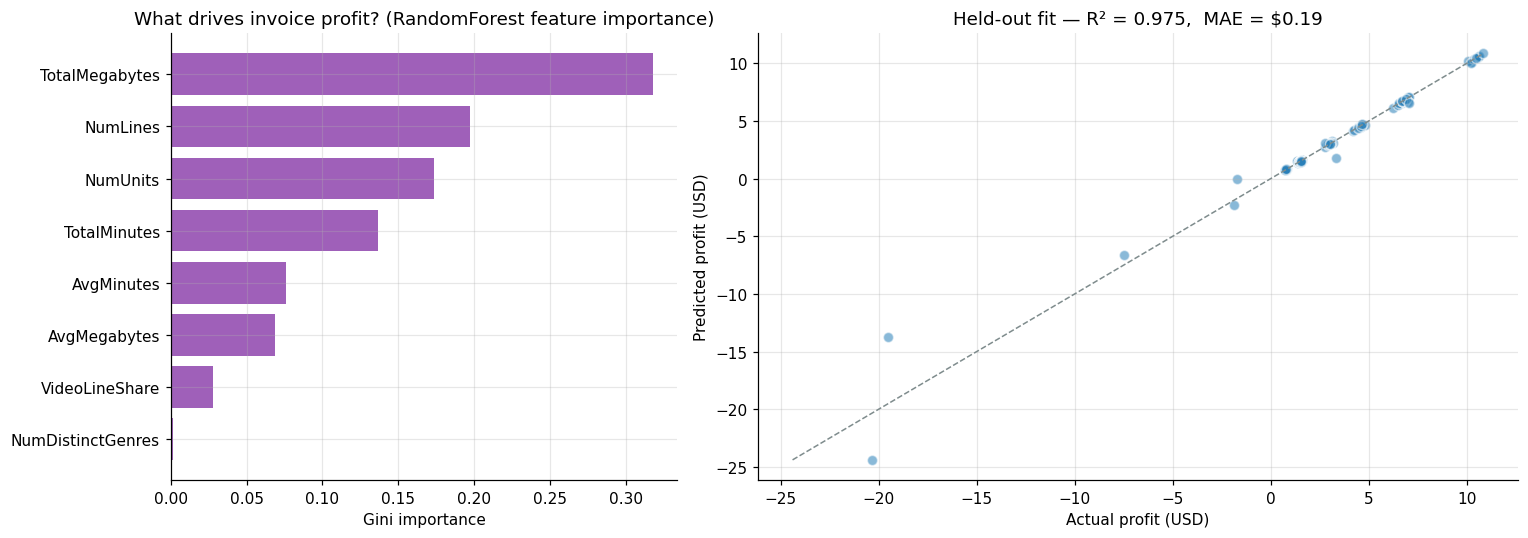

,importance
TotalMegabytes,0.3183
NumLines,0.1977
NumUnits,0.1738
TotalMinutes,0.1365
AvgMinutes,0.0760
AvgMegabytes,0.0685
VideoLineShare,0.0275
NumDistinctGenres,0.0017


In [42]:
importances = (
    pd.Series(model.feature_importances_, index=X.columns)
    .sort_values(ascending=True)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [2, 3]})

ax1.barh(importances.index, importances.values, color="#8E44AD", alpha=0.85)
ax1.set_xlabel("Gini importance")
ax1.set_title("What drives invoice profit? (RandomForest feature importance)")

ax2.scatter(y_test, y_pred, alpha=0.55, color="#2980B9", edgecolor="white", s=45)
lo, hi = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
ax2.plot([lo, hi], [lo, hi], "--", color="#7F8C8D", lw=1)
ax2.set_xlabel("Actual profit (USD)")
ax2.set_ylabel("Predicted profit (USD)")
ax2.set_title(f"Held-out fit — R² = {metrics['R²']:.3f},  MAE = ${metrics['MAE ($)']:.2f}")

plt.tight_layout()
plt.show()

importances.sort_values(ascending=False).to_frame("importance").round(4)

### 7.3 Profit-first genre recommendations by country

For each of the largest markets, rank genres by **profit contribution** (not revenue). This surfaces genres worth promoting even when their revenue looks unremarkable, and flags "revenue-rich but margin-poor" genres to avoid featuring in campaigns. Both the country baseline and the top-3 promotion picks are shown side-by-side.

In [43]:
TOP_N_COUNTRIES = 10
TOP_K_GENRES = 3

top_countries = country_summary.head(TOP_N_COUNTRIES)["Country"].tolist()

country_genre = (
    sales_cost_master[sales_cost_master["Country"].isin(top_countries)]
    .groupby(["Country", "GenreName"], as_index=False)
    .agg(
        Lines=("InvoiceLineId", "count"),
        Revenue=("Revenue", "sum"),
        Profit=("Profit", "sum"),
    )
)
country_genre["Margin"] = country_genre["Profit"] / country_genre["Revenue"]
country_genre["ProfitPerLine"] = country_genre["Profit"] / country_genre["Lines"]

rows = []
for country in top_countries:
    sub = country_genre[country_genre["Country"] == country].sort_values("Profit", ascending=False)
    top = sub.head(TOP_K_GENRES)
    worst = sub.tail(1)
    rows.append(
        {
            "Country": country,
            "Recommended genres (by profit)": ", ".join(
                f"{g} (${p:.2f}, {m*100:.0f}%)" for g, p, m in zip(top["GenreName"], top["Profit"], top["Margin"])
            ),
            "Avoid featuring": (
                f"{worst.iloc[0]['GenreName']} (${worst.iloc[0]['Profit']:.2f}, {worst.iloc[0]['Margin']*100:.0f}%)"
                if worst.iloc[0]["Profit"] < 0 or worst.iloc[0]["Margin"] < 0.4
                else "—"
            ),
        }
    )

recommendations = pd.DataFrame(rows)
recommendations

,Country,Recommended genres (by profit),Avoid featuring
0,USA,"Rock ($115.96, 75%), Latin ($69.49, 77%), Meta...","TV Shows ($-23.96, -86%)"
1,Canada,"Rock ($80.37, 76%), Latin ($45.26, 76%), Metal...","Drama ($-7.10, -178%)"
2,France,"Rock ($48.74, 76%), Alternative & Punk ($23.72...","Drama ($-19.21, -241%)"
3,Brazil,"Rock ($61.10, 76%), Latin ($40.75, 78%), Metal...","Sci Fi & Fantasy ($-7.56, -190%)"
4,Germany,"Rock ($46.62, 76%), Metal ($18.66, 75%), Latin...","TV Shows ($-10.27, -172%)"
5,United Kingdom,"Rock ($27.50, 75%), Latin ($23.34, 76%), Metal...",—
6,Czech Republic,"Rock ($18.62, 75%), Latin ($7.00, 79%), Altern...","Drama ($-20.41, -171%)"
7,Portugal,"Rock ($23.55, 77%), Latin ($9.78, 76%), Metal ...","Sci Fi & Fantasy ($-3.86, -194%)"
8,India,"Rock ($18.48, 75%), Alternative & Punk ($8.40,...","Sci Fi & Fantasy ($-3.72, -187%)"
9,Chile,"Rock ($6.83, 77%), Latin ($5.84, 74%), Easy Li...","Drama ($-14.46, -182%)"


In [44]:
rev_top3 = (
    country_genre.sort_values(["Country", "Revenue"], ascending=[True, False])
    .groupby("Country")
    .head(3)
    .assign(rank_type="by_revenue")
)
prof_top3 = (
    country_genre.sort_values(["Country", "Profit"], ascending=[True, False])
    .groupby("Country")
    .head(3)
    .assign(rank_type="by_profit")
)
compare = (
    pd.concat([rev_top3, prof_top3])
    .pivot_table(
        index=["Country", "GenreName"], columns="rank_type", values="Profit", aggfunc="first",
    )
    .fillna("")
)

changes = []
for country in top_countries:
    rev_set = set(country_genre.query("Country == @country").nlargest(3, "Revenue")["GenreName"])
    prof_set = set(country_genre.query("Country == @country").nlargest(3, "Profit")["GenreName"])
    added = prof_set - rev_set
    dropped = rev_set - prof_set
    changes.append(
        {
            "Country": country,
            "Promoted_by_profit_ranking": ", ".join(sorted(added)) or "—",
            "Demoted_by_profit_ranking": ", ".join(sorted(dropped)) or "—",
        }
    )
pd.DataFrame(changes)

,Country,Promoted_by_profit_ranking,Demoted_by_profit_ranking
0,USA,—,—
1,Canada,—,—
2,France,—,—
3,Brazil,—,—
4,Germany,—,—
5,United Kingdom,—,—
6,Czech Republic,"Alternative & Punk, Latin","Drama, TV Shows"
7,Portugal,—,—
8,India,—,—
9,Chile,Easy Listening,Drama
